In [1]:
from datetime import datetime, timedelta
from stk_pred.entities.stock import Stock
from pandas import DataFrame, concat

mag7_tech = ["AAPL","NVDA","META","INTC","AMZN","GOOGL","MSFT"]
mag7_health = ["LLY","NVO","VRTX","ABBV","ISRG","HCA", "UNH", "HIMS"]
mag7_financial = ["V","MA","PYPL","AXP","BLK"]  
other = ["INTC","AVGO","RDDT","UBER","SNOW"]
df = DataFrame()
for symbol in mag7_tech + mag7_health + mag7_financial + other:
    stock = Stock(symbol=symbol, company=symbol)
    stock.populate_ratings()
    _df = stock.ratings.to_frame(); _df["stk"] = stock.symbol
    df = concat([df, _df])
cutoff = (datetime.now() - timedelta(days=60)).date()
df = df[df["date"] >= cutoff]
df;

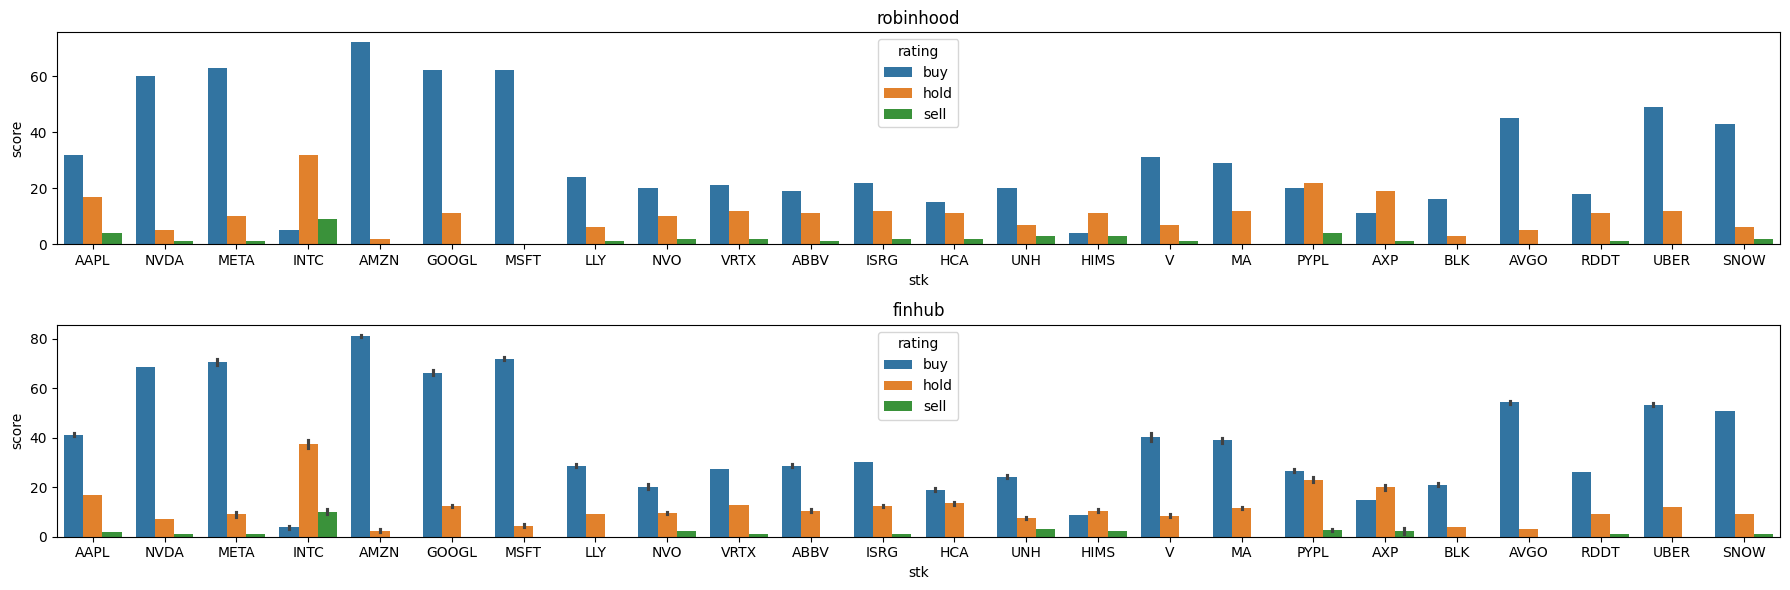

In [2]:
import seaborn as sns
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = subplots(nrows=2,ncols=1,figsize=(18,6)); #fig.subplots_adjust(hspace=0.25)
df_melted = df.melt(id_vars=["date", "stk", "source"], value_vars=["buy", "hold", "sell"], var_name="rating", value_name="score")
sources = df_melted["source"].unique()
for idx, src in enumerate(sources):
    sns.barplot(data=df_melted[df_melted["source"] == src], x="stk", y="score", hue="rating", ax=ax[idx])
    ax[idx].set_title(src)
fig.tight_layout()

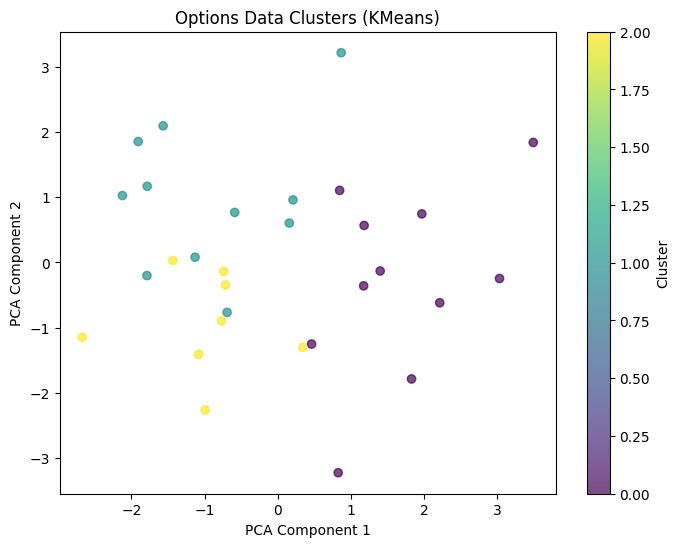

         date ticker    spot  cluster
0  2025-07-31   AAPL  210.75        1
1  2025-08-01   AAPL  210.54        0
2  2025-08-02   AAPL  211.51        0
3  2025-08-03   AAPL  213.79        1
4  2025-08-04   AAPL  213.44        1
5  2025-08-05   AAPL  213.09        2
6  2025-08-06   AAPL  215.46        1
7  2025-08-07   AAPL  216.61        1
8  2025-08-08   AAPL  215.91        2
9  2025-08-09   AAPL  216.72        1
10 2025-08-10   AAPL  216.03        2
11 2025-08-11   AAPL  215.33        1
12 2025-08-12   AAPL  215.69        1
13 2025-08-13   AAPL  212.82        2
14 2025-08-14   AAPL  210.23        1
15 2025-08-15   AAPL  209.39        0
16 2025-08-16   AAPL  207.87        0
17 2025-08-17   AAPL  208.34        1
18 2025-08-18   AAPL  206.98        0
19 2025-08-19   AAPL  204.86        0
20 2025-08-20   AAPL  207.06        2
21 2025-08-21   AAPL  206.72        0
22 2025-08-22   AAPL  206.82        2
23 2025-08-23   AAPL  204.69        0
24 2025-08-24   AAPL  203.87        0
25 2025-08-2

In [3]:
# clustering/options_clustering.py

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


def load_data(csv_path: str) -> pd.DataFrame:
    """Load options features dataset."""
    df = pd.read_csv(csv_path, parse_dates=["date"])
    return df


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Select and scale numerical features for clustering."""
    feature_cols = [
        "put_call_volume_ratio",
        "put_call_oi_ratio",
        "avg_iv_calls",
        "avg_iv_puts",
        "iv_skew",
        "vwap_strike_calls",
        "vwap_strike_puts",
        "strike_bias",
    ]
    X = df[feature_cols].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled


def cluster_data(X_scaled, n_clusters=3, random_state=42):
    """Apply KMeans clustering."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    return labels, kmeans


def reduce_dimensions(X_scaled, n_components=2):
    """Apply PCA for visualization."""
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    return X_pca


def plot_clusters(X_pca, labels):
    """Plot clusters in 2D PCA space."""
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", alpha=0.7)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Options Data Clusters (KMeans)")
    plt.colorbar(scatter, label="Cluster")
    plt.show()


csv_path = "options_features.csv"  # replace with your actual path
df = load_data(csv_path)
X_scaled = preprocess_data(df)
labels, kmeans = cluster_data(X_scaled, n_clusters=3)
X_pca = reduce_dimensions(X_scaled)
plot_clusters(X_pca, labels)

# attach labels back to df
df["cluster"] = labels
print(df[["date", "ticker", "spot","cluster"]])

